In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 2006-01-01 to 2008-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 1998-01-01 to 2000-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 2012-01-01 to 2014-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 2018-01-01 to 2020-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 2022-01-01 to 2024-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 2016-01-01 to 2018-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 1996-01-01 to 1998-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 2020-01-01 to 2022-01-01.csv
/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 1994-01-01 to 1996-01-01.csv
/kaggle/input/datasets/alfredkondoro/

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import math
from IPython.display import display

TIME_COL = "datetime"
STATE_COL = "icon"

DATA_PATH = "/kaggle/input/datasets/alfredkondoro/seoul-historical-weather-data-2024/seoul 2022-01-01 to 2024-01-01.csv"

# # Optional filter theo thời gian (để None nếu lấy hết)
# START_DATE = None
# END_DATE   = None

# Visualization controls
TOPK_EDGES_PER_NODE = 10
MATRIX_TICK_LIMIT   = 20

# Periodicity computation limit
MAX_RETURN_N = 200

EPS = 1e-12

In [3]:
df_raw = pd.read_csv(DATA_PATH)

if TIME_COL not in df_raw.columns:
    raise ValueError(f"Missing TIME_COL='{TIME_COL}'. Columns: {list(df_raw.columns)}")
if STATE_COL not in df_raw.columns:
    raise ValueError(f"Missing STATE_COL='{STATE_COL}'. Columns: {list(df_raw.columns)}")

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (731, 33)


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,seoul,2022-01-01,2.0,-10.2,-4.7,0.3,-15.0,-6.6,-15.2,44.3,...,9.9,5,NaN,2022-01-01T07:46:54,2022-01-01T17:24:04,0.94,Clear,Clear conditions throughout the day.,clear-day,"47098099999,47112099999,47119099999,4712209999..."
1,seoul,2022-01-02,2.6,-4.4,-1.1,-0.5,-8.6,-4.0,-8.4,58.9,...,10.1,5,NaN,2022-01-02T07:47:03,2022-01-02T17:24:52,0.98,"Snow, Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,"47111099999,47098099999,47112099999,4711909999..."
2,seoul,2022-01-03,2.2,-7.7,-2.4,0.6,-11.5,-4.7,-10.1,56.4,...,9.8,5,NaN,2022-01-03T07:47:10,2022-01-03T17:25:41,0.00,"Snow, Rain, Partially cloudy",Becoming cloudy in the afternoon with late aft...,rain,"47111099999,47098099999,47112099999,4711909999..."
3,seoul,2022-01-04,1.0,-5.0,-1.9,0.6,-9.1,-4.7,-10.6,54.8,...,10.9,5,NaN,2022-01-04T07:47:15,2022-01-04T17:26:32,0.04,Snow,Clear conditions throughout the day with late ...,rain,"47111099999,47098099999,47112099999,4711909999..."
4,seoul,2022-01-05,1.7,-7.7,-3.1,1.7,-12.0,-4.9,-13.0,46.7,...,6.1,3,NaN,2022-01-05T07:47:18,2022-01-05T17:27:23,0.08,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"47111099999,47098099999,47112099999,4711909999..."


### Defining State Space, Time Parameters, and Time Range

In [4]:
def stable_mode(series: pd.Series) -> str:
    vc = series.value_counts()
    top = vc[vc == vc.max()].index.astype(str).tolist()
    return sorted(top)[0]  # nếu hoà, chọn theo alphabet

def to_daily_mode(df: pd.DataFrame, time_col: str, state_col:str) -> pd.DataFrame:
    x = df.copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x = x.dropna(subset=[time_col, state_col]).copy()

    x[state_col] = x[state_col].astype(str).str.strip().str.lower()

    x["date"] = x[time_col].dt.date
    daily = (
        x.groupby("date")[state_col]
         .apply(stable_mode)
         .reset_index()
         .sort_values("date")
         .reset_index(drop=True)
    )
    return daily

daily = to_daily_mode(df_raw, TIME_COL, STATE_COL)

seq = daily[STATE_COL].values
states = sorted(pd.unique(seq).tolist())
s2i = {s:i for i,s in enumerate(states)}
m = len(states)

print("Daily rows:", len(daily))
print("Num states:", m)
print("State examples:", states[:10])
daily.head()

Daily rows: 731
Num states: 5
State examples: ['clear-day', 'cloudy', 'partly-cloudy-day', 'rain', 'snow']


,date,icon
0,2022-01-01,clear-day
1,2022-01-02,rain
2,2022-01-03,rain
3,2022-01-04,rain
4,2022-01-05,partly-cloudy-day


### Visualizing the Markov Chain

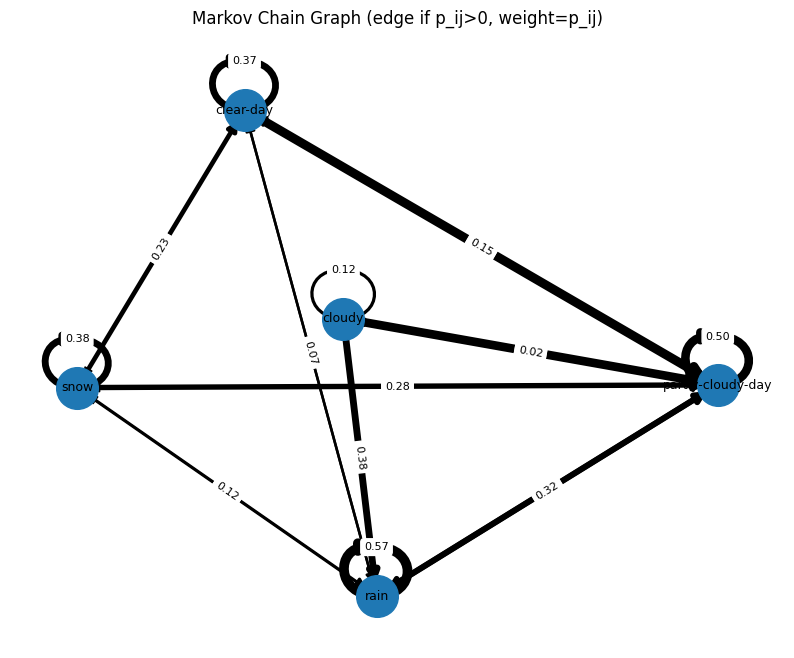

In [5]:
# Ước lượng p_ij = count(i->j) / sum_j count(i->j) (ước lượng tần suất)
def transition_counts_from_seq(seq, s2i, m):
    C = np.zeros((m, m), dtype=np.float64)
    for a, b in zip(seq[:-1], seq[1:]):
        C[s2i[a], s2i[b]] += 1.0
    return C

C = transition_counts_from_seq(seq, s2i, m)

# Ma trận chuyển P: stochastic matrix (mỗi hàng tổng = 1, không âm).
# Nếu một state không có outgoing transitions (row sum = 0), ta gán p_ii=1 để vẫn là stochastic,
# đồng thời không "bịa" thêm cạnh ra ngoài (chỉ self-loop). Điều này giữ đúng điều kiện ∑_j p_ij=1.
P = np.zeros_like(C)
row_sums = C.sum(axis=1)

for i in range(m):
    if row_sums[i] > 0:
        P[i] = C[i] / row_sums[i]
    else:
        P[i, i] = 1.0

# Vẽ graph theo định nghĩa: có cạnh i->j nếu p_ij > 0, weight = p_ij
G = nx.DiGraph()
G.add_nodes_from(states)

for i, s_from in enumerate(states):
    probs = P[i]
    # để đỡ rối: chỉ vẽ TOPK cạnh lớn nhất từ mỗi node
    top_js = np.argsort(probs)[::-1][:TOPK_EDGES_PER_NODE]
    for j in top_js:
        if probs[j] > 0:
            G.add_edge(s_from, states[j], weight=float(probs[j]))

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=7)

edge_w = np.array([G[u][v]["weight"] for u, v in G.edges()]) if G.number_of_edges() else np.array([1.0])
widths = 1.0 + 6.0 * (edge_w / (edge_w.max() + EPS))

nx.draw_networkx_nodes(G, pos, node_size=900)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, arrows=True, width=widths, arrowstyle="-|>", arrowsize=14)

if G.number_of_edges() <= 40:
    edge_labels = {(u, v): f'{G[u][v]["weight"]:.2f}' for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Markov Chain Graph (edge if p_ij>0, weight=p_ij)")
plt.axis("off")
plt.show()

### Creating and Visualizing the One-Step Transition Matrix (P)

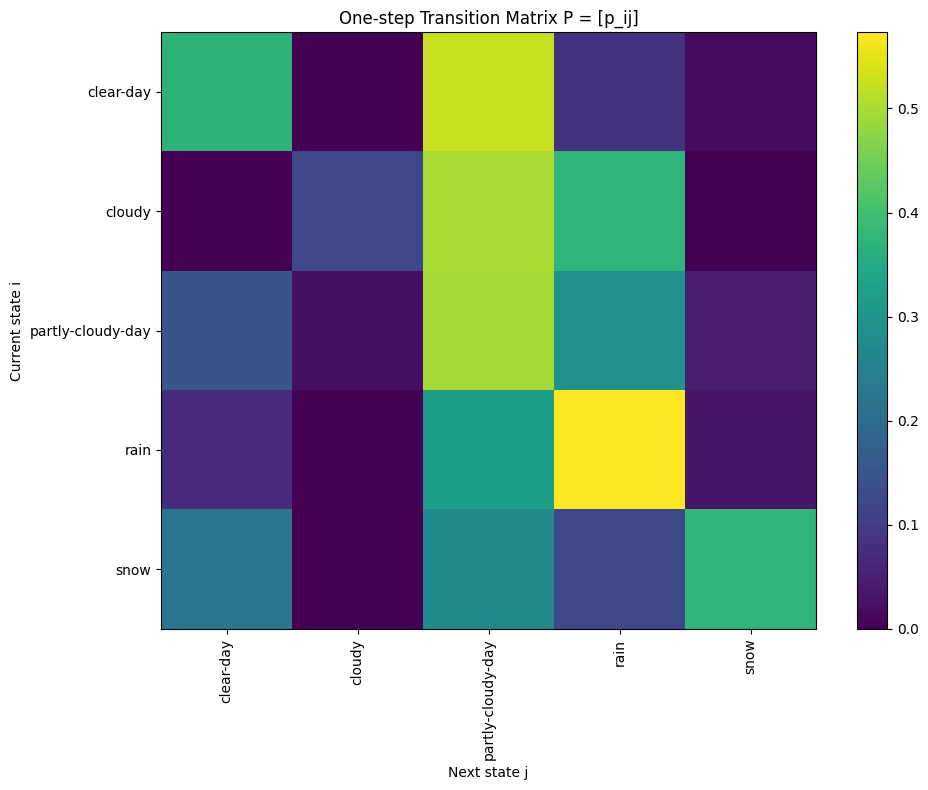

,clear-day,cloudy,partly-cloudy-day,rain,snow
clear-day,0.372881,0.000000,0.525424,0.084746,0.016949
cloudy,0.000000,0.125000,0.500000,0.375000,0.000000
partly-cloudy-day,0.147910,0.022508,0.495177,0.289389,0.045016
rain,0.071146,0.000000,0.320158,0.573123,0.035573
snow,0.225000,0.000000,0.275000,0.125000,0.375000


In [6]:
plt.figure(figsize=(10, 8))
plt.imshow(P, aspect="auto")
plt.title("One-step Transition Matrix P = [p_ij]")
plt.xlabel("Next state j")
plt.ylabel("Current state i")
plt.colorbar()

if m <= MATRIX_TICK_LIMIT:
    plt.xticks(range(m), states, rotation=90)
    plt.yticks(range(m), states)
else:
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

P_df = pd.DataFrame(P, index=states, columns=states)
display(P_df.iloc[: min(10,m), : min(10,m)])

### Generating and Visualizing P^3, P^10, and P^100 Probability Matrices

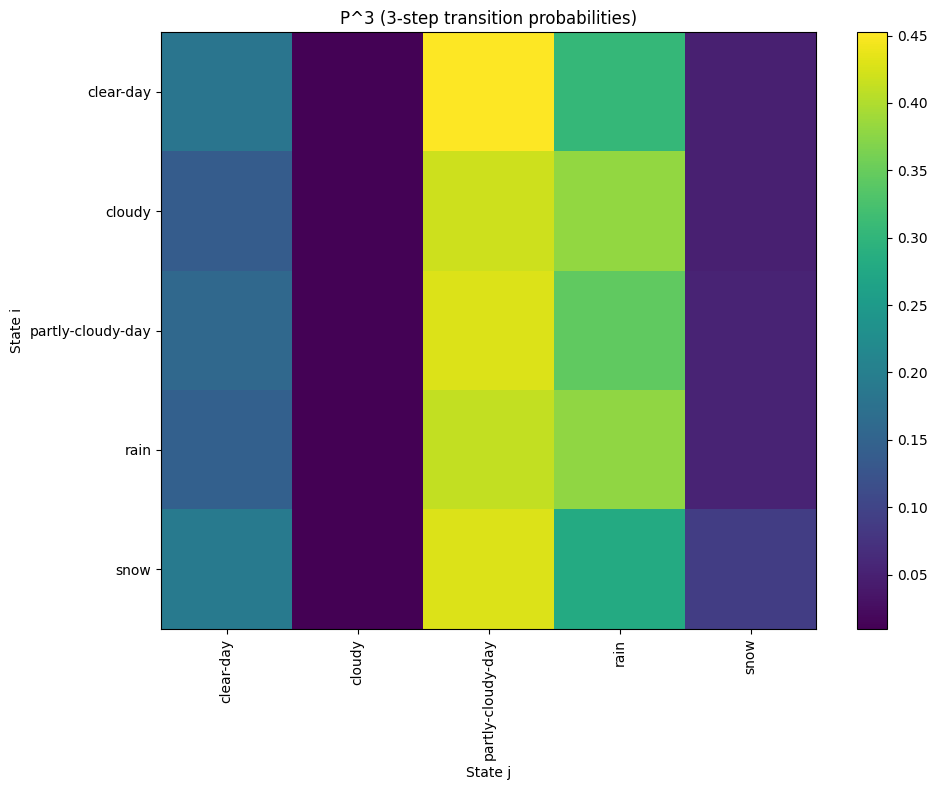

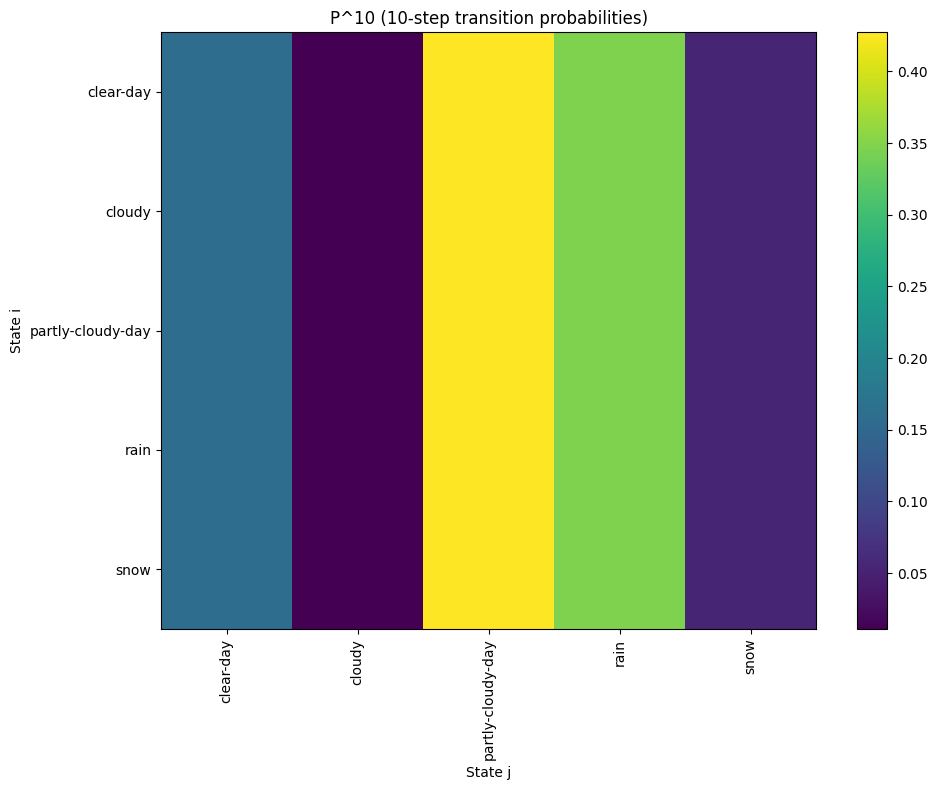

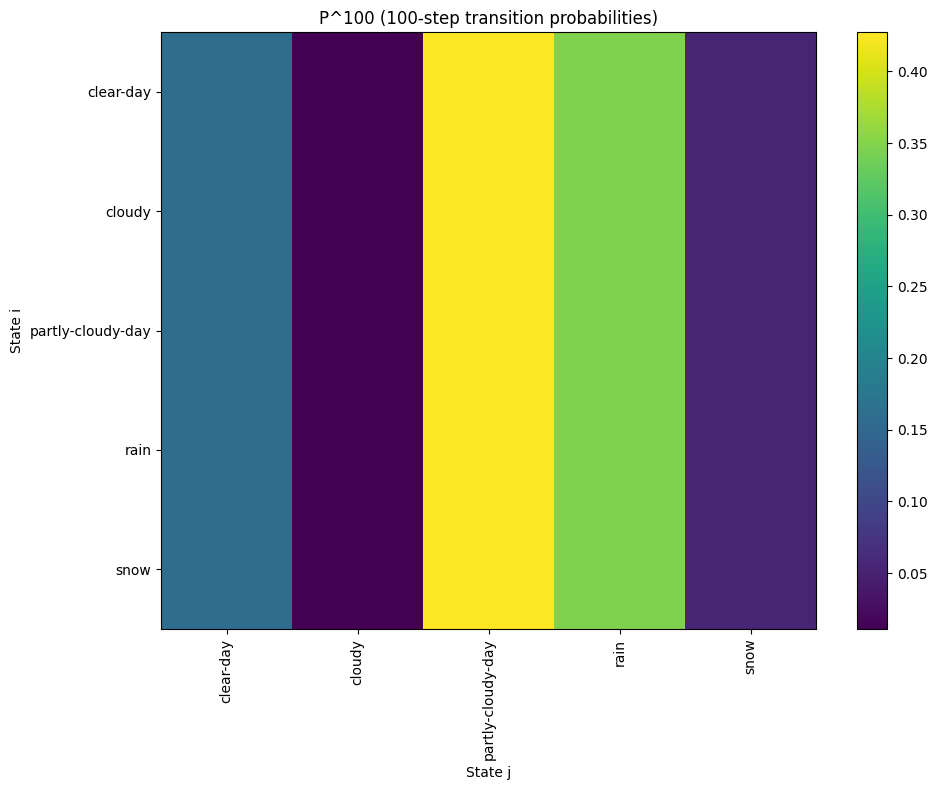

In [7]:
# Theo Chapman–Kolmogorov, xác suất n bước là P^n.
def show_heatmap(M, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(M, aspect="auto")
    plt.title(title)
    plt.xlabel("State j")
    plt.ylabel("State i")
    plt.colorbar()
    if M.shape[0] <= MATRIX_TICK_LIMIT:
        plt.xticks(range(M.shape[0]), states, rotation=90)
        plt.yticks(range(M.shape[0]), states)
    else:
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()

P3   = np.linalg.matrix_power(P, 3)
P10  = np.linalg.matrix_power(P, 10)
P100 = np.linalg.matrix_power(P, 100)

show_heatmap(P3,   "P^3 (3-step transition probabilities)")
show_heatmap(P10,  "P^10 (10-step transition probabilities)")
show_heatmap(P100, "P^100 (100-step transition probabilities)")

### Analyzing Irreducibility, Closed Sets, Periodicity, and Absorbing States

In [8]:
# Graph cấu trúc đúng định nghĩa: edge i->j nếu p_ij > 0
G_struct = nx.DiGraph()
G_struct.add_nodes_from(range(m))
for i in range(m):
    for j in range(m):
        if P[i, j] > 0:
            G_struct.add_edge(i, j)

# Irreducible: mọi trạng thái liên thông (i ↔ j, ∀i,j)
is_irreducible = nx.is_strongly_connected(G_struct)
print("Irreducible (strongly connected)?", is_irreducible)

# Communication classes = SCC
sccs = list(nx.strongly_connected_components(G_struct))
print("Num SCCs:", len(sccs))
print("Largest SCC sizes:", sorted([len(c) for c in sccs], reverse=True)[:5])

# Closed sets (closed communicating classes): SCC không có cạnh đi ra ngoài
closed_classes = []
for comp in sccs:
    closed = True
    for u in comp:
        for v in G_struct.successors(u):
            if v not in comp:
                closed = False
                break
        if not closed:
            break
    if closed:
        closed_classes.append(comp)

print("\nNum closed communicating classes:", len(closed_classes))
for k, comp in enumerate(closed_classes[:10], start=1):
    names = [states[i] for i in sorted(comp)]
    print(f"Closed class {k} (size={len(comp)}):", names)

# Absorbing state: p_ii = 1
absorbing = [states[i] for i in range(m) if np.isclose(P[i, i], 1.0)]
print("\nAbsorbing states (p_ii=1):", absorbing if absorbing else "None")

# Recurrent vs Transient (thực hành hữu hạn):
# Trạng thái trong closed communicating class là recurrent; còn lại là transient.
recurrent_idx = set().union(*closed_classes) if closed_classes else set()
transient_idx = set(range(m)) - recurrent_idx
print("\nRecurrent states (sample):", [states[i] for i in sorted(list(recurrent_idx))[:10]])
print("Transient states (sample):", [states[i] for i in sorted(list(transient_idx))[:10]])

# Periodicity theo đúng định nghĩa:
# d(i) = gcd{ n >= 1 : (P^n)_{ii} > 0 }.
# Ta dùng adjacency boolean A_ij = 1 nếu p_ij>0, vì (P^n)_{ii}>0 <-> tồn tại đường đi dài n quay lại i.
A = (P > 0)

def gcd_list(nums):
    g = 0
    for x in nums:
        g = math.gcd(g, int(x))
    return g

def return_times(A_bool, i, max_n=200):
    M = A_bool.copy()
    times = []
    for n in range(1, max_n + 1):
        if M[i, i]:
            times.append(n)
        M = (M @ A_bool) > 0
    return times

def period_of_state(A_bool, i, max_n=200):
    times = return_times(A_bool, i, max_n=max_n)
    if len(times) == 0:
        return None
    return gcd_list(times)

# Trong 1 SCC, period là như nhau; lấy gcd trên vài state để chắc
period_info = []
for comp in sccs:
    comp = sorted(list(comp))
    ds = []
    for i in comp[: min(5, len(comp))]:  # lấy tối đa 5 state đại diện
        di = period_of_state(A, i, max_n=MAX_RETURN_N)
        if di is not None:
            ds.append(di)
    d_comp = gcd_list(ds) if ds else None
    period_info.append((len(comp), d_comp, [states[i] for i in comp]))

period_info = sorted(period_info, key=lambda x: (-x[0], 999 if x[1] is None else x[1]))
print("\nSCC periodicity (top 5 SCC by size):")
for size, per, names in period_info[:5]:
    print(f"- size={size}, period={per}, sample_states={names[:8]}")

Irreducible (strongly connected)? True
Num SCCs: 1
Largest SCC sizes: [5]

Num closed communicating classes: 1
Closed class 1 (size=5): ['clear-day', 'cloudy', 'partly-cloudy-day', 'rain', 'snow']

Absorbing states (p_ii=1): None

Recurrent states (sample): ['clear-day', 'cloudy', 'partly-cloudy-day', 'rain', 'snow']
Transient states (sample): []

SCC periodicity (top 5 SCC by size):
- size=5, period=1, sample_states=['clear-day', 'cloudy', 'partly-cloudy-day', 'rain', 'snow']


### Checking for Irreducibility and Calculating the Stationary Distribution

In [9]:
# Stationary distribution: π = πP, π_j>=0, sum π_j = 1.
# Nếu ergodic (irreducible + aperiodic) => π duy nhất và µ^(n)=µ^(0) P^n hội tụ về π.

def stationary_power(P, tol=1e-12, max_iter=200000):
    pi = np.ones(P.shape[0], dtype=np.float64) / P.shape[0]
    for _ in range(max_iter):
        pi_new = pi @ P
        if np.linalg.norm(pi_new - pi, ord=1) < tol:
            pi = pi_new
            break
        pi = pi_new
    pi = np.maximum(pi, 0)
    return pi / (pi.sum() + EPS)

def stationary_via_left_eig(P):
    w, v = np.linalg.eig(P.T)
    k = int(np.argmin(np.abs(w - 1.0)))
    pi = np.real(v[:, k])
    pi = np.maximum(pi, 0)
    return pi / (pi.sum() + EPS)

# Aperiodic? (nếu irreducible thì chỉ cần period của SCC duy nhất; nếu reducible thì xét SCC lớn nhất)
aperiodic = False
if is_irreducible:
    _, per_all, _ = period_info[0]
    aperiodic = (per_all == 1)
    print("Aperiodic (period=1)?", aperiodic)

is_ergodic = is_irreducible and aperiodic
print("Ergodic? (irreducible & aperiodic)", is_ergodic)

if is_ergodic:
    # Có thể dùng power method (bám µ^(n+1)=µ^(n)P) hoặc eigen.
    pi = stationary_power(P)
    pi_df = pd.DataFrame({"state": states, "pi_stationary": pi}).sort_values("pi_stationary", ascending=False)
    print("\nUnique stationary distribution π (ergodic). Top 15:")
    display(pi_df.head(15))
else:
    print("\nChain is NOT ergodic -> stationary distribution is not necessarily unique on whole S.")
    print("Ta báo π trong từng closed communicating class (recurrent class) bằng nghiệm π=πP (trong lớp đó):\n")

    out = []
    for cid, comp in enumerate(closed_classes, start=1):
        idx = sorted(list(comp))
        P_sub = P[np.ix_(idx, idx)]
        pi_sub = stationary_via_left_eig(P_sub)

        for local_i, global_i in enumerate(idx):
            out.append({
                "closed_class_id": cid,
                "state": states[global_i],
                "pi_within_class": float(pi_sub[local_i]),
                "class_size": len(idx)
            })

    pi_classes_df = pd.DataFrame(out).sort_values(["closed_class_id", "pi_within_class"], ascending=[True, False])
    display(pi_classes_df)

Aperiodic (period=1)? True
Ergodic? (irreducible & aperiodic) True

Unique stationary distribution π (ergodic). Top 15:


,state,pi_stationary
2,partly-cloudy-day,0.427239
3,rain,0.347083
0,clear-day,0.159827
4,snow,0.054861
1,cloudy,0.010990
